# Home value appreciation (ATXRNSA)

Monthly **All-Transactions House Price Index** for the U.S. (seasonally adjusted). Source file: `data/home_appreciation/ATXRNSA.csv`.

This notebook:

1. Loads the series and treats `observation_date` as the monthly period.
2. Estimates **long-run average appreciation** from historical index changes (monthly log returns, YoY % change, and full-sample CAGR).
3. Fits **Prophet** on the index level and projects **60 months** (~5 years) ahead, then summarizes implied growth over that horizon.

> Install Prophet if needed: uncomment `%pip install -q prophet` at the top of the imports cell and run that cell once.

In [1]:
# Uncomment if Prophet is not installed in your environment
# %pip install -q prophet

import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

DATA_PATH = Path("../data/home_appreciation/ATXRNSA.csv")

df = pd.read_csv(DATA_PATH, parse_dates=["observation_date"])
df = df.rename(columns={"observation_date": "period"})
df = df.sort_values("period").reset_index(drop=True)
df = df.dropna(subset=["ATXRNSA"])
df.head()

,period,ATXRNSA
0,1991-01-01,69.610578
1,1991-02-01,69.172916
2,1991-03-01,69.047657
3,1991-04-01,69.401637
4,1991-05-01,69.688718


## Long-run average appreciation

We summarize appreciation several ways so the “average” is not sensitive to a single definition:

- **Annualized from mean monthly log return:** \(\exp(12 \cdot \overline{r}) - 1\) where \(r_t = \ln(I_t) - \ln(I_{t-1})\).
- **Mean / median YoY % change** in the index (12-month percent change).
- **Full-sample CAGR** on the index from first to last observation.

In [2]:
df["log_index"] = np.log(df["ATXRNSA"])
df["mom_log_return"] = df["log_index"].diff()

mean_mom_log = df["mom_log_return"].mean()
annualized_from_mom = float(np.expm1(12 * mean_mom_log))

df["yoy_pct"] = df["ATXRNSA"].pct_change(12) * 100
mean_yoy = df["yoy_pct"].mean()
median_yoy = df["yoy_pct"].median()

start, end = df["period"].iloc[0], df["period"].iloc[-1]
years_span = (end - start).days / 365.25
cagr_full = (df["ATXRNSA"].iloc[-1] / df["ATXRNSA"].iloc[0]) ** (1 / years_span) - 1

print(f"Sample: {start.date()} → {end.date()} ({len(df)} months, ~{years_span:.1f} years)")
print(f"Mean monthly log return: {mean_mom_log * 100:.4f}% (per month)")
print(f"Implied annualized appreciation from mean monthly log return: {annualized_from_mom * 100:.2f}% / year")
print(f"Mean YoY % change in index: {mean_yoy:.2f}%")
print(f"Median YoY % change in index: {median_yoy:.2f}%")
print(f"Full-sample CAGR on index: {cagr_full * 100:.2f}% / year")

Sample: 1991-01-01 → 2026-01-01 (421 months, ~35.0 years)
Mean monthly log return: 0.3002% (per month)
Implied annualized appreciation from mean monthly log return: 3.67% / year
Mean YoY % change in index: 4.04%
Median YoY % change in index: 4.43%
Full-sample CAGR on index: 3.67% / year


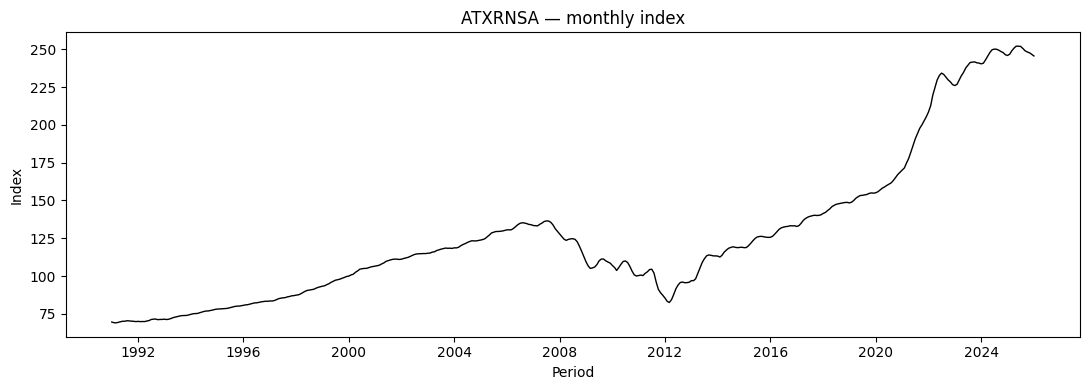

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df["period"], df["ATXRNSA"], color="black", linewidth=1)
ax.set_title("ATXRNSA — monthly index")
ax.set_xlabel("Period")
ax.set_ylabel("Index")
plt.tight_layout()
plt.show()

## Prophet: 5-year projection (60 monthly steps)

Prophet is fit to the **index level** (`y` = ATXRNSA, `ds` = month start). The **2021–2023** window (COVID-era spike) is **dropped from training** so the model does not learn from that episode.

**Testing:** a second fit uses **pre-2021 data only**; we score **post-2023 actuals** (MAE / MAPE), so spike years are not in the training or test windows.

The main forecast still runs **60 months beyond the latest observed month** in the full series. Interval bands reflect model uncertainty, not macro scenarios.

In [4]:
from prophet import Prophet

SPIKE_START = pd.Timestamp("2021-01-01")
SPIKE_END = pd.Timestamp("2023-12-01")

prophet_df = df[["period", "ATXRNSA"]].rename(columns={"period": "ds", "ATXRNSA": "y"})
spike_mask = (prophet_df["ds"] >= SPIKE_START) & (prophet_df["ds"] <= SPIKE_END)
prophet_train = prophet_df.loc[~spike_mask].copy()

print(
    f"Full history: {len(prophet_df)} mo | Training (spike excluded): {len(prophet_train)} mo | "
    f"Dropped {int(spike_mask.sum())} mo ({SPIKE_START.date()} … {SPIKE_END.date()})"
)

m = Prophet(
    seasonality_mode="multiplicative",
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
)
m.fit(prophet_train)

future = m.make_future_dataframe(periods=60, freq="MS")
forecast = m.predict(future)

forecast.tail(8)

Full history: 421 mo | Training (spike excluded): 385 mo | Dropped 36 mo (2021-01-01 … 2023-12-01)


12:55:05 - cmdstanpy - INFO - Chain [1] start processing
12:55:05 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
437,2030-06-01,315.876698,306.298798,331.419586,304.908298,325.558027,0.010608,0.010608,0.010608,0.010608,0.010608,0.010608,0.0,0.0,0.0,319.227673
438,2030-07-01,317.015608,308.015089,334.542365,305.769173,326.975889,0.012976,0.012976,0.012976,0.012976,0.012976,0.012976,0.0,0.0,0.0,321.129353
439,2030-08-01,318.192482,307.484618,335.095624,306.570039,328.272180,0.010421,0.010421,0.010421,0.010421,0.010421,0.010421,0.0,0.0,0.0,321.508429
440,2030-09-01,319.369356,306.596378,334.301137,307.360621,329.556352,0.003997,0.003997,0.003997,0.003997,0.003997,0.003997,0.0,0.0,0.0,320.645894
441,2030-10-01,320.508266,305.728905,333.479257,308.121670,331.069573,-0.001893,-0.001893,-0.001893,-0.001893,-0.001893,-0.001893,0.0,0.0,0.0,319.901530
442,2030-11-01,321.685139,304.037399,332.583263,308.935869,332.382622,-0.008501,-0.008501,-0.008501,-0.008501,-0.008501,-0.008501,0.0,0.0,0.0,318.950565
443,2030-12-01,322.824049,303.754855,331.856462,309.758460,333.883363,-0.013556,-0.013556,-0.013556,-0.013556,-0.013556,-0.013556,0.0,0.0,0.0,318.447714
444,2031-01-01,324.000923,307.113924,336.333880,310.698454,335.476477,-0.005192,-0.005192,-0.005192,-0.005192,-0.005192,-0.005192,0.0,0.0,0.0,322.318711


In [5]:
# Train only on pre-spike months; evaluate on post-spike actuals (2021–2023 not in train or test).
train_pre_spike = prophet_df[prophet_df["ds"] < SPIKE_START].copy()
test_post_spike = prophet_df[prophet_df["ds"] > SPIKE_END].copy()

m_test = Prophet(
    seasonality_mode="multiplicative",
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
)
m_test.fit(train_pre_spike)

train_max = train_pre_spike["ds"].max()
last_test_ds = test_post_spike["ds"].max()
extra_months = (last_test_ds.year - train_max.year) * 12 + (last_test_ds.month - train_max.month)

future_test = m_test.make_future_dataframe(periods=extra_months, freq="MS")
fc_test = m_test.predict(future_test)

cmp = fc_test[["ds", "yhat"]].merge(test_post_spike, on="ds", how="inner")
mae = (cmp["yhat"] - cmp["y"]).abs().mean()
mape = ((cmp["yhat"] - cmp["y"]).abs() / cmp["y"]).mean() * 100

print(f"Backtest train: {len(train_pre_spike)} mo (ends {train_max.date()})")
print(f"Backtest test:  {len(cmp)} post-spike months ({cmp['ds'].min().date()} … {cmp['ds'].max().date()})")
print(f"MAE: {mae:.4f} | MAPE: {mape:.2f}%")

12:55:09 - cmdstanpy - INFO - Chain [1] start processing
12:55:10 - cmdstanpy - INFO - Chain [1] done processing


Backtest train: 360 mo (ends 2020-12-01)
Backtest test:  25 post-spike months (2024-01-01 … 2026-01-01)
MAE: 53.8355 | MAPE: 21.73%


In [6]:
last_actual_date = prophet_df["ds"].max()
last_actual_y = float(prophet_df.loc[prophet_df["ds"] == last_actual_date, "y"].iloc[0])

fc_future = forecast[forecast["ds"] > last_actual_date]
fc_end = fc_future.iloc[-1]
proj_end_date = fc_end["ds"]
proj_yhat = float(fc_end["yhat"])

horizon_years = 5.0
total_growth = proj_yhat / last_actual_y - 1
cagr_5y = (proj_yhat / last_actual_y) ** (1 / horizon_years) - 1

print(f"Last observed: {last_actual_date.date()}  index = {last_actual_y:.4f}")
print(f"Prophet ~5y ahead ({proj_end_date.date()}): yhat = {proj_yhat:.4f}")
print(f"Implied total index change over horizon: {total_growth * 100:.2f}%")
print(f"Implied CAGR over horizon: {cagr_5y * 100:.2f}% / year")

Last observed: 2026-01-01  index = 245.5855
Prophet ~5y ahead (2031-01-01): yhat = 322.3187
Implied total index change over horizon: 31.25%
Implied CAGR over horizon: 5.59% / year


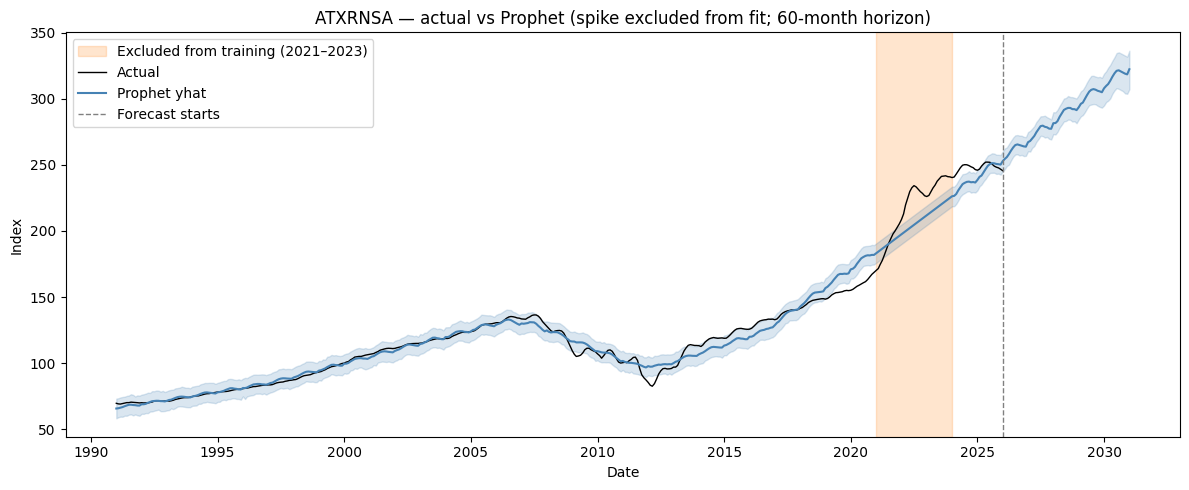

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.axvspan(
    SPIKE_START,
    SPIKE_END + pd.DateOffset(months=1),
    color="tab:orange",
    alpha=0.2,
    label="Excluded from training (2021–2023)",
)
ax.plot(prophet_df["ds"], prophet_df["y"], label="Actual", color="black", linewidth=1)
ax.plot(forecast["ds"], forecast["yhat"], label="Prophet yhat", color="steelblue")
ax.fill_between(
    forecast["ds"],
    forecast["yhat_lower"],
    forecast["yhat_upper"],
    color="steelblue",
    alpha=0.2,
)
ax.axvline(last_actual_date, color="gray", linestyle="--", linewidth=1, label="Forecast starts")
ax.set_title("ATXRNSA — actual vs Prophet (spike excluded from fit; 60-month horizon)")
ax.set_xlabel("Date")
ax.set_ylabel("Index")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

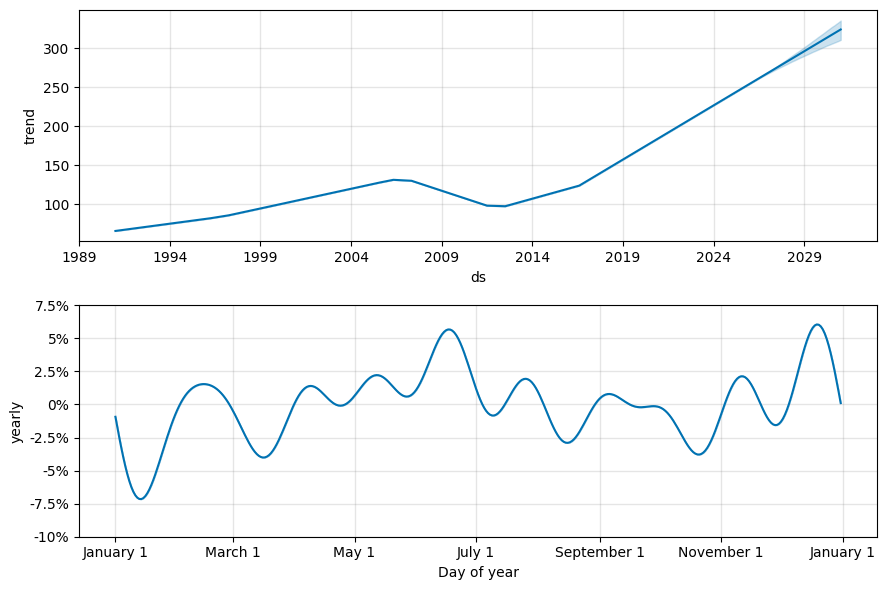

In [8]:
fig2 = m.plot_components(forecast)
plt.show()